In [1]:
# importing packages
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import conductivity as cd
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Data

## KCl

In [2]:
# loading KCl specific conductivity data
specific_data_probe1 = pd.read_csv("./Data/KCl_Probe1.csv")
specific_data_probe2 = pd.read_csv("./Data/KCl_Probe2.csv")

molar_conc_specific = specific_data_probe1["KCl Conc"]

specific_cond_exp1_raw = specific_data_probe1["Cond"]
specific_cond_exp2_raw = specific_data_probe2["Cond"]

# number of data points
ndata_K = len(specific_cond_exp1_raw)

# calibrated probe 1 data
specific_cond_calibrated_exp1_raw = specific_data_probe1["Cond_cal"]

# convert the conductivity from micro.S/cm to milli.S/cm
specific_cond_exp1 = [specific_cond_exp1_raw[i]/1000 for i in range(ndata_K)]
specific_cond_calibrated_exp1 = [specific_cond_calibrated_exp1_raw[i]/1000 
                                 for i in range(ndata_K)]
specific_cond_exp2 = [specific_cond_exp2_raw[i]/1000 for i in range(ndata_K)]

## Probe 1 and Probe 2 measurement errors

In [3]:
# average conductivity between probes
specific_cond_avg = (specific_cond_exp1_raw + specific_cond_exp2_raw) / 2

# percent error of each probe relative to the average
percent_error_probe1 = np.abs((specific_cond_exp1_raw - specific_cond_avg) / 
                              specific_cond_avg) * 100
percent_error_probe2 = np.abs((specific_cond_exp2_raw - specific_cond_avg) / 
                              specific_cond_avg) * 100

# Mean absolute percent error
mape_probe1 = np.mean(percent_error_probe1)
mape_probe2 = np.mean(percent_error_probe2)

print("Mean absolute percent error of Probe 1:", mape_probe1)
print("Mean absolute percent error of Probe 2:", mape_probe2)

# measurement error
error_K = [(mape_probe1/100) * specific_cond_calibrated_exp1[i] for i in range(ndata_K)]
error_K_uncal = [(mape_probe1/100) * specific_cond_exp1[i] for i in range(ndata_K)]
error_K_uncal_2 = [(mape_probe2/100) * specific_cond_exp2[i] for i in range(ndata_K)]

Mean absolute percent error of Probe 1: 0.9332932911243101
Mean absolute percent error of Probe 2: 0.933293291124311


## National Institute of Standards and Technology (NIST) reference values

In [4]:
# load the NIST standards
nist_standard = pd.read_csv("./Data/NIST_KCl.csv")
molar_conc_nist = nist_standard["KCl Conc"]
nist_cond_raw = nist_standard["NIST Cond"]

# number of NIST data points
ndata_NIST = len(nist_cond_raw)
nist_cond = [nist_cond_raw[i]/1000 for i in range(ndata_NIST)]
error_nist = [0.0025 * nist_cond[i] for i in range(ndata_NIST)]

## NaCl

In [5]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/NaCl.csv")
molar_conc_specific_Na = specific_data["NaCl conc"]
specific_cond_exp_Na_raw = specific_data["NaCl cond"]
specific_cond_calibrated_Na_raw = specific_data["NaCl cond cal"]

# number of data points
ndata_Na = len(specific_cond_exp_Na_raw)

# convert the conductivity from micro.S/cm to milli.S/cm
specific_cond_exp_Na = [specific_cond_exp_Na_raw[i]/1000 for i in range(ndata_Na)]
specific_cond_calibrated_Na = [specific_cond_calibrated_Na_raw[i]/1000 
                               for i in range(ndata_Na)]

# measurement error
error_Na = [(mape_probe1/100) * specific_cond_calibrated_Na[i] for i in range(ndata_Na)]
error_Na_uncal = [(mape_probe1/100) * specific_cond_exp_Na[i] for i in range(ndata_Na)]

## CaCl2

In [6]:
# loading CaCl2 specific conductivity data
specific_data = pd.read_csv("./Data/CaCl2.csv")
molar_conc_specific_Ca_fig = specific_data["CaCl2_conc"]
specific_cond_exp_Ca_raw = specific_data["CaCl2_cond"]
specific_cond_calibrated_Ca_fig_raw = specific_data["CaCl2_cond_cal"]

# number of data points
ndata_Ca_fig = len(specific_cond_exp_Ca_raw)

# convert the conductivity from micro.S/cm to milli.S/cm
specific_cond_exp_Ca = [specific_cond_exp_Ca_raw[i]/1000 for i in range(ndata_Ca_fig)]
specific_cond_calibrated_Ca_fig = [specific_cond_calibrated_Ca_fig_raw[i]/1000 
                                   for i in range(ndata_Ca_fig)]

# measurement error
error_Ca = [(mape_probe1/100) * specific_cond_calibrated_Ca_fig[i] 
            for i in range(ndata_Ca_fig)]
error_Ca_uncal = [(mape_probe1/100) * specific_cond_exp_Ca[i] 
                  for i in range(ndata_Ca_fig)]

## LaCl3

In [7]:
# loading LaCl3 specific conductivity data
specific_data = pd.read_csv("./Data/LaCl3.csv")
molar_conc_specific_La_fig = specific_data["LaCl3 conc"]
specific_cond_exp_La_raw = specific_data["LaCl3 cond"]
specific_cond_calibrated_La_fig_raw = specific_data["LaCl3 cond cal"]

# number of data points
ndata_La_fig = len(specific_cond_exp_La_raw)

# convert the conductivity from micro.S/cm to milli.S/cm
specific_cond_exp_La = [specific_cond_exp_La_raw[i]/1000 for i in range(ndata_La_fig)]
specific_cond_calibrated_La_fig = [specific_cond_calibrated_La_fig_raw[i]/1000 
                                   for i in range(ndata_La_fig)]

# measurement error
error_La = [(mape_probe1/100) * specific_cond_calibrated_La_fig[i] 
            for i in range(ndata_La_fig)]
error_La_uncal = [(mape_probe1/100) * specific_cond_exp_La[i] 
                  for i in range(ndata_La_fig)]

# Mean spherical approximation (MSA) model

In [8]:
# temperature in K
T = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
Diff_K = 1.957 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
z_K = 1

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
sigma_K = 2 * 138 * 10**(-12)

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_K_mol = 73.48 * 10**(-4)

## NaCl conductivity predictions

In [9]:
# constants
diff_coeff_na_cl = [Diff_Na, Diff_Cl] # diffusion coefficients of Na and Cl, respectively
valency_na_cl = [z_Na, z_Cl] # valencies of Na and Cl, respectively
diameter_na_cl = [sigma_Na, sigma_Cl] # effective ionic diameters of Na and Cl, respectively
lambda_0_na_cl = [lambda_0_Na_mol, lambda_0_Cl_mol] # limiting molar conductivity of Na and Cl, respectively

# predicted conductivity in milli.S/cm
msa_cond_calc_nacl =cd.msa(valency_na_cl, diameter_na_cl, diff_coeff_na_cl, T, eta_msa, 
                           epsilon, lambda_0_na_cl, molar_conc_specific_Na)

Relaxation correction: [-0.04592817 -0.04592817]
Hydrodynamic correction: [-0.15303697 -0.09425016]
Relative ionic strength: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Ionic mobility: [3.23986816e+11 4.93509152e+11]
Average mobility: 408747984038.1848
Alpha: [np.float64(0.0), np.float64(399863050038.09155)]
zeta matrix: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]


## KCl conductivity predictions

In [10]:
# constants
diff_coeff_k_cl = [Diff_K, Diff_Cl]
valency_k_cl = [z_K, z_Cl]
diameter_k_cl = [sigma_K, sigma_Cl]
lambda_0_k_cl = [lambda_0_K_mol, lambda_0_Cl_mol]

# predicted conductivity in milli.S/cm
msa_cond_calc_kcl =cd.msa(valency_k_cl, diameter_k_cl, diff_coeff_k_cl, T, eta_msa, 
                          epsilon, lambda_0_k_cl, molar_conc_specific)

Relaxation correction: [-0.04348786 -0.04348786]
Hydrodynamic correction: [-0.09967594 -0.09280948]
Relative ionic strength: [0.5 0.5]
Transport number: [0.49059915 0.50940085]
Ionic mobility: [4.75294002e+11 4.93509152e+11]
Average mobility: 484401577043.46985
Alpha: [np.float64(0.0), np.float64(484315950503.38934)]
zeta matrix: [[ 1.01898183 -1.        ]
 [ 0.98137177  1.        ]]


## CaCl2 conductivity predictions

In [11]:
# constants
diff_coeff_ca_cl = [Diff_Ca, Diff_Cl]
valency_ca_cl = [z_Ca, z_Cl]
diameter_ca_cl = [sigma_Ca, sigma_Cl]
lambda_0_ca_cl = [lambda_0_Ca_mol, lambda_0_Cl_mol]

# predicted conductivity in milli.S/cm
msa_cond_calc_cacl2 =cd.msa(valency_ca_cl, diameter_ca_cl, diff_coeff_ca_cl, T, eta_msa, 
                            epsilon, lambda_0_ca_cl, molar_conc_specific_Ca_fig)

Relaxation correction: [-0.10818585 -0.10818585]
Hydrodynamic correction: [-0.39791399 -0.14075783]
Relative ionic strength: [0.66666667 0.33333333]
Transport number: [0.4380531 0.5619469]
Ionic mobility: [1.92351992e+11 4.93509152e+11]
Average mobility: 292737712474.16846
Alpha: [np.float64(0.0), np.float64(357043456714.51733)]
zeta matrix: [[ 1.38221033 -0.61018268]
 [ 0.53873552  1.22036535]]


## LaCl3 conductivity predictions

In [12]:
# constants
diff_coeff_la_cl = [Diff_La, Diff_Cl]
valency_la_cl = [z_La, z_Cl]
diameter_la_cl = [sigma_La, sigma_Cl]
lambda_0_la_cl = [lambda_0_La_mol, lambda_0_Cl_mol]

# predicted conductivity in milli.S/cm
msa_cond_calc_lacl3 =cd.msa(valency_la_cl, diameter_la_cl, diff_coeff_la_cl, T, eta_msa, 
                            epsilon, lambda_0_la_cl, molar_conc_specific_La_fig)

Relaxation correction: [-0.12637157 -0.12637157]
Hydrodynamic correction: [-0.41013329 -0.11737156]
Relative ionic strength: [0.75 0.25]
Transport number: [0.47750064 0.52249936]
Ionic mobility: [1.50335711e+11 4.93509152e+11]
Average mobility: 236129071587.12134
Alpha: [np.float64(0.0), np.float64(357917325038.46246)]
zeta matrix: [[ 1.37883561 -0.43937499]
 [ 0.42002915  1.31812498]]


## Plotting the results

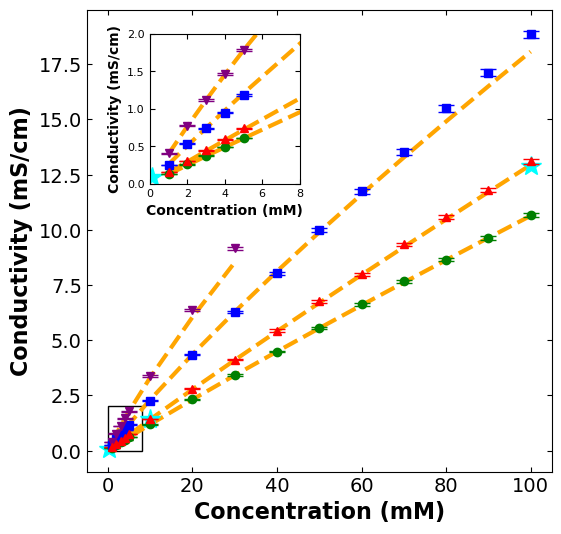

In [13]:
# plot comparing model predictions with probe 1 data
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, label="MSA")
ax.plot(molar_conc_specific_Na, msa_cond_calc_nacl, "--", color="orange", linewidth=3)
ax.plot(molar_conc_specific_Ca_fig, msa_cond_calc_cacl2, "--", color="orange", linewidth=3)
ax.plot(molar_conc_specific_La_fig, msa_cond_calc_lacl3, "--", color="orange", linewidth=3)
ax.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", label="NIST (KCl) Standard")
ax.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', 
    capsize=6, markersize=6, markerfacecolor='green', markeredgecolor='green', label='NaCl Data')
ax.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', 
    capsize=6, markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
ax.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', 
    capsize=6, markersize=6, markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
ax.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='KCl Data')
ax.set_xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
ax.set_ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
ax.tick_params(labelsize=14, direction="in",top=True, right=True)

# define zoom region (clustered area)
zoom_xlim = (0, 8)
zoom_ylim = (0, 2)

# draw rectangle on main plot to show zoom area
ax.add_patch(
    plt.Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0],
        zoom_ylim[1] - zoom_ylim[0],
        fill=False
    )
)

# create inset axes on top left
inset_ax = fig.add_axes([0.23, 0.59, 0.25, 0.25])  # [left, bottom, width, height]

# plot the zoomed region
# repeat your plot data
inset_ax.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, label="MSA")
inset_ax.plot(molar_conc_specific_Na, msa_cond_calc_nacl, "--", color="orange", linewidth=3)
inset_ax.plot(molar_conc_specific_Ca_fig, msa_cond_calc_cacl2, "--", color="orange", linewidth=3)
inset_ax.plot(molar_conc_specific_La_fig, msa_cond_calc_lacl3, "--", color="orange", linewidth=3)
inset_ax.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", label="NIST (KCl) Standard")
inset_ax.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='NaCl Data')
inset_ax.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', 
    capsize=6, markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
inset_ax.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', 
    capsize=6, markersize=6, markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
inset_ax.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='KCl Data')
inset_ax.set_xlim(zoom_xlim)
inset_ax.set_ylim(zoom_ylim)
inset_ax.set_xlabel("Concentration (mM)", fontsize=10,fontweight='bold')
inset_ax.set_ylabel("Conductivity (mS/cm)", fontsize=10,fontweight='bold')
inset_ax.tick_params(labelsize=8, direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.savefig(r".\Single_salt\msa_single_all.png")
plt.show()

The mean absolute percent error of KCl is: 1.4624924405186368
The mean absolute percent error of NaCl is: 1.0091292707877493
The mean absolute percent error of CaCl2 is: 2.282134652189731
The mean absolute percent error of LaCl3 is: 2.205055976163839

The mean absolute error of KCl is: 0.047171464657425034
The mean absolute error of NaCl is: 0.016846710840333224
The mean absolute error of CaCl2 is: 0.17930074306185873
The mean absolute error of LaCl3 is: 0.13247502832909233

The mean squared error of KCl is: 0.004474953574426886
The mean squared error of NaCl is: 0.000614278001419438
The mean squared error of CaCl2 is: 0.09466989290522386
The mean squared error of LaCl3 is: 0.06346533898906931


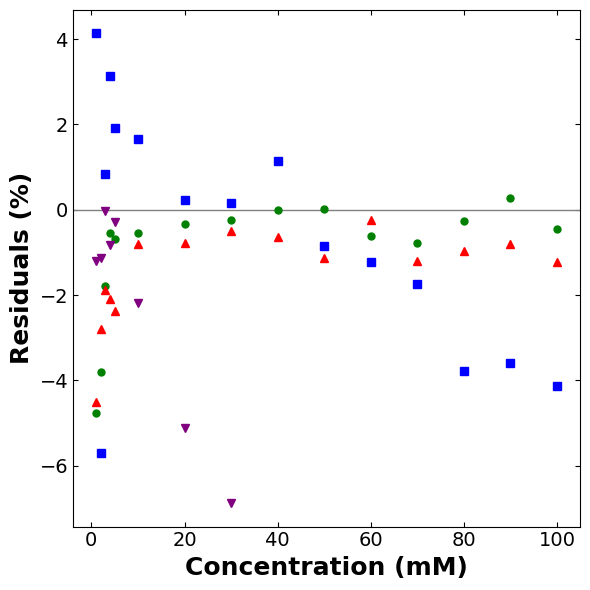

In [14]:
# prediction residuals for probe 1 KCl, NaCl, CaCl2, and LaCl3 data
e_K_fig_MSA = [msa_cond_calc_kcl[i]- specific_cond_calibrated_exp1[i] 
               for i in range(ndata_K)]
e_Na_fig_MSA = [msa_cond_calc_nacl[i]- specific_cond_calibrated_Na[i] 
                for i in range(ndata_Na)]
e_Ca_fig_MSA = [msa_cond_calc_cacl2[i] - specific_cond_calibrated_Ca_fig[i] 
                for i in range(ndata_Ca_fig)]
e_La_fig_MSA = [msa_cond_calc_lacl3[i] - specific_cond_calibrated_La_fig[i] 
                for i in range(ndata_La_fig)]

# percent prediction residuals
residuals_percent_K_MSA = [100*e_K_fig_MSA[i]/specific_cond_calibrated_exp1[i] 
                           for i in range(ndata_K)]
residuals_percent_Na_MSA = [100*e_Na_fig_MSA[i]/specific_cond_calibrated_Na[i] 
                            for i in range(ndata_Na)]
residuals_percent_Ca_MSA = [100*e_Ca_fig_MSA[i]/specific_cond_calibrated_Ca_fig[i] 
                            for i in range(ndata_Ca_fig)]
residuals_percent_La_MSA = [100*e_La_fig_MSA[i]/specific_cond_calibrated_La_fig[i] 
                            for i in range(ndata_La_fig)]

# calculate the mean absolute percent error
residuals_percent_K_abs_MSA = [np.abs(residuals_percent_K_MSA[i]) 
                               for i in range(ndata_K)]
residuals_percent_Na_abs_MSA = [np.abs(residuals_percent_Na_MSA[i]) 
                                for i in range(ndata_Na)]
residuals_percent_Ca_abs_MSA = [np.abs(residuals_percent_Ca_MSA[i]) 
                                for i in range(ndata_Ca_fig)]
residuals_percent_La_abs_MSA = [np.abs(residuals_percent_La_MSA[i]) 
                                for i in range(ndata_La_fig)]
print("The mean absolute percent error of KCl is:",np.mean(residuals_percent_K_abs_MSA))
print("The mean absolute percent error of NaCl is:",np.mean(residuals_percent_Na_abs_MSA))
print("The mean absolute percent error of CaCl2 is:",np.mean(residuals_percent_Ca_abs_MSA))
print("The mean absolute percent error of LaCl3 is:",np.mean(residuals_percent_La_abs_MSA))

# calculate the mean absolute error
residuals_K_abs_MSA = [np.abs(e_K_fig_MSA[i]) for i in range(ndata_K)]
residuals_Na_abs_MSA = [np.abs(e_Na_fig_MSA[i]) for i in range(ndata_Na)]
residuals_Ca_abs_MSA = [np.abs(e_Ca_fig_MSA[i]) for i in range(ndata_Ca_fig)]
residuals_La_abs_MSA = [np.abs(e_La_fig_MSA[i]) for i in range(ndata_La_fig)]
print("\nThe mean absolute error of KCl is:",np.mean(residuals_K_abs_MSA))
print("The mean absolute error of NaCl is:",np.mean(residuals_Na_abs_MSA))
print("The mean absolute error of CaCl2 is:",np.mean(residuals_Ca_abs_MSA))
print("The mean absolute error of LaCl3 is:",np.mean(residuals_La_abs_MSA))

# calculate the mean squared error
sq_residuals_K_MSA = [e_K_fig_MSA[i]**2 for i in range(ndata_K)]
sq_residuals_Na_MSA = [e_Na_fig_MSA[i]**2 for i in range(ndata_Na)]
sq_residuals_Ca_MSA = [e_Ca_fig_MSA[i]**2 for i in range(ndata_Ca_fig)]
sq_residuals_La_MSA = [e_La_fig_MSA[i]**2 for i in range(ndata_La_fig)]
print("\nThe mean squared error of KCl is:",np.mean(sq_residuals_K_MSA))
print("The mean squared error of NaCl is:",np.mean(sq_residuals_Na_MSA))
print("The mean squared error of CaCl2 is:",np.mean(sq_residuals_Ca_MSA))
print("The mean squared error of LaCl3 is:",np.mean(sq_residuals_La_MSA))

# plot the prediction residuals
fig = plt.figure(figsize=(6, 6))
plt.axhline(0, color="0.5", lw=1)
plt.plot(molar_conc_specific_Na, residuals_percent_Na_MSA, "g.", markersize=10, 
         label="NaCl")
plt.plot(molar_conc_specific_Ca_fig, residuals_percent_Ca_MSA, "s", color="blue", 
         label="CaCl$\mathbf{_2}$")
plt.plot(molar_conc_specific, residuals_percent_K_MSA, "^", color="red", 
         label="KCl")
plt.plot(molar_conc_specific_La_fig, residuals_percent_La_MSA, "v", color="purple", 
         label="LaCl$\mathbf{_3}$")
plt.xlabel("Concentration (mM)", fontsize=18,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=18,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Single_salt\MSA_single_all_residuals.png")
plt.show()

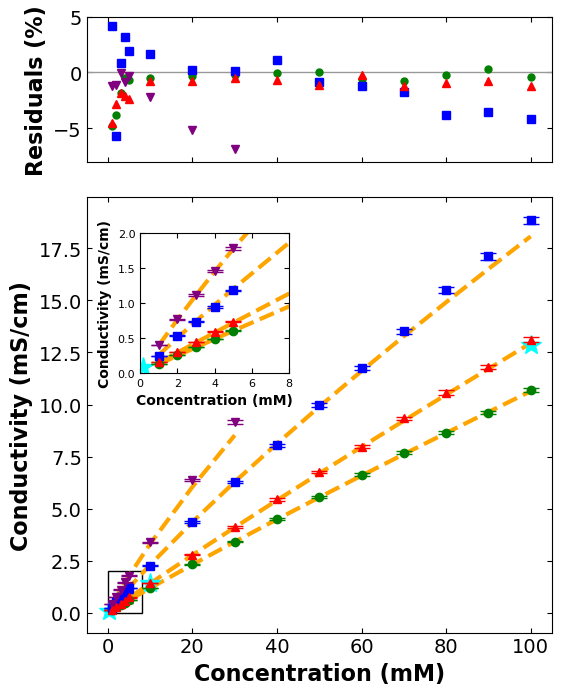

In [15]:
# generate paper figure for the MSA model
fig = plt.figure(figsize=(6, 8))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.12)

ax_res = fig.add_subplot(gs[0])
ax_cond = fig.add_subplot(gs[1], sharex=ax_res)

# top plot
ax_res.axhline(0, color="0.6", lw=1)
ax_res.plot(molar_conc_specific_Na, residuals_percent_Na_MSA, "g.", markersize=10, 
            label="NaCl")
ax_res.plot(molar_conc_specific_Ca_fig, residuals_percent_Ca_MSA, "s", color="blue", 
            label="CaCl$\mathbf{_2}$")
ax_res.plot(molar_conc_specific, residuals_percent_K_MSA, "^", color="red", label="KCl")
ax_res.plot(molar_conc_specific_La_fig, residuals_percent_La_MSA, "v", color="purple", 
            label="LaCl$\mathbf{_3}$")

ax_res.set_ylabel("Residuals (%)", fontsize=16, fontweight="bold")
ax_res.set_ylim(-8, 5)
ax_res.tick_params(direction="in", top=True, right=True, labelsize=14)
plt.setp(ax_res.get_xticklabels(), visible=False)

# bottom plot
ax_cond.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, label="MSA")
ax_cond.plot(molar_conc_specific_Na, msa_cond_calc_nacl, "--", color="orange", linewidth=3)
ax_cond.plot(molar_conc_specific_Ca_fig, msa_cond_calc_cacl2, "--", color="orange", linewidth=3)
ax_cond.plot(molar_conc_specific_La_fig, msa_cond_calc_lacl3, "--", color="orange", linewidth=3)
ax_cond.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", label="NIST (KCl) Standard")
ax_cond.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', 
    capsize=6, markersize=6, markerfacecolor='green', markeredgecolor='green', label='NaCl Data')
ax_cond.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', 
    capsize=6, markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
ax_cond.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', 
    capsize=6, markersize=6,  markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
ax_cond.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='KCl Data')

ax_cond.set_xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
ax_cond.set_ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
ax_cond.tick_params(labelsize=14, direction="in",top=True, right=True)

ax_inset = inset_axes(
    ax_cond,
    width="40%", 
    height="40%",
    bbox_to_anchor=(0.1, 0.58, 0.8, 0.8),
    bbox_transform=ax_cond.transAxes,
    loc="lower left"
)

# plot subset
ax_inset.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, label="MSA")
ax_inset.plot(molar_conc_specific_Na, msa_cond_calc_nacl, "--", color="orange", linewidth=3)
ax_inset.plot(molar_conc_specific_Ca_fig, msa_cond_calc_cacl2, "--", color="orange", linewidth=3)
ax_inset.plot(molar_conc_specific_La_fig, msa_cond_calc_lacl3, "--", color="orange", linewidth=3)
ax_inset.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", label="NIST (KCl) Standard")
ax_inset.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='NaCl Data')
ax_inset.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', 
    capsize=6, markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
ax_inset.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', 
    capsize=6, markersize=6, markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
ax_inset.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='KCl Data')

ax_inset.set_xlim(0, 8)
ax_inset.set_ylim(0, 2)
ax_inset.set_xlabel("Concentration (mM)", fontsize=10,fontweight='bold')
ax_inset.set_ylabel("Conductivity (mS/cm)", fontsize=10,fontweight='bold')
ax_inset.tick_params(labelsize=8, direction="in",top=True, right=True)

# define zoom region (clustered area)
zoom_xlim = (0, 8)
zoom_ylim = (0, 2)
ax_cond.add_patch(
    plt.Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0],
        zoom_ylim[1] - zoom_ylim[0],
        fill=False
    )
)
plt.savefig(r".\Single_salt\MSA_single_all_final.png")
plt.show()


# Shedlovsky Model

## NaCl, KCl, CaCl2, and LaCl3 conductivity predictions

In [16]:
# concentration in M
conc_Na = [molar_conc_specific_Na[i]*10**(-3) for i in range(ndata_Na)]
conc_K = [molar_conc_specific[i]*10**(-3) for i in range(ndata_K)]
conc_Ca_fig = [molar_conc_specific_Ca_fig[i]*10**(-3) for i in range(ndata_Ca_fig)]
conc_La_fig = [molar_conc_specific_La_fig[i]*10**(-3) for i in range(ndata_La_fig)]

# KCl constants
eta_shed = 8.9*10**(-3) # poise
lambda_0_KCl = 149.85 # cm^2.Siemen.equiv^(-1)
lambda_0_K = 73.50 # cm^2.Siemen.equiv^(-1)
lambda_0_Cl = 76.35 # cm^2.Siemen.equiv^(-1)
a_KCl = 4.6*10**(-8) # cm
z_K = 1 # cation valency
z_Cl = -1 # anion valency

# KCl conductivity in milli.S/cm
specific_cond_calc = cd.shedlovsky(conc_K, T, epsilon, eta_shed, lambda_0_KCl, 
                                   a_KCl, z_K, z_Cl, lambda_0_K, lambda_0_Cl)

# NaCl constants
lambda_0_NaCl = 126.45 # cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 # cm^2.Siemen.equiv^(-1)
a_NaCl = 4*10**(-8) # cm
z_Na = 1

# NaCl conductivity in milli.S/cm
specific_cond_calc_Na = cd.shedlovsky(conc_Na, T, epsilon, eta_shed, lambda_0_NaCl, 
                                      a_NaCl, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)

# CaCl2 constants
lambda_0_CaCl2 = 135.85 # cm^2.Siemen.equiv^(-1)
a_CaCl2 = 4.31*10**(-8) # cm
lambda_0_Ca = 59.5 # cm^2.Siemen.equiv^(-1)
z_Ca = 2

# CaCl2 conductivity in milli.S/cm
specific_cond_calc_Ca_fig = cd.shedlovsky(conc_Ca_fig, T, epsilon, eta_shed, lambda_0_CaCl2, 
                                          a_CaCl2, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)

# LaCl3 constants
lambda_0_LaCl3 = 145.9 # cm^2.Siemen.equiv^(-1)
a_LaCl3 = 4.9*10**(-8) # cm
lambda_0_La = 69.7 # cm^2.Siemen.equiv^(-1)
z_La = 3

# LaCl3 conductivity in milli.S/cm
specific_cond_calc_La_fig = cd.shedlovsky(conc_La_fig, T, epsilon, eta_shed, lambda_0_LaCl3, 
                                          a_LaCl3, z_La, z_Cl, lambda_0_La, lambda_0_Cl)

In [17]:
# prediction residuals for probe 1 NaCl, KCl, CaCl2, and LaCl3 data
e_Na_fig = [specific_cond_calc_Na[i]- specific_cond_calibrated_Na[i] 
            for i in range(ndata_Na)]
e_K_fig = [specific_cond_calc[i] - specific_cond_calibrated_exp1[i] 
           for i in range(ndata_K)]
e_Ca_fig = [specific_cond_calc_Ca_fig[i] - specific_cond_calibrated_Ca_fig[i] 
            for i in range(ndata_Ca_fig)]
e_La_fig = [specific_cond_calc_La_fig[i] - specific_cond_calibrated_La_fig[i] 
            for i in range(ndata_La_fig)]

# percent prediction residuals
residuals_percent_Na = [100*e_Na_fig[i]/specific_cond_calibrated_Na[i] 
                        for i in range(ndata_Na)]
residuals_percent_K = [100*e_K_fig[i]/specific_cond_calibrated_exp1[i] 
                       for i in range(ndata_K)]
residuals_percent_Ca = [100*e_Ca_fig[i]/specific_cond_calibrated_Ca_fig[i] 
                        for i in range(ndata_Ca_fig)]
residuals_percent_La = [100*e_La_fig[i]/specific_cond_calibrated_La_fig[i] 
                        for i in range(ndata_La_fig)]

# calculate the mean absolute percent error
residuals_percent_Na_abs = [np.abs(residuals_percent_Na[i]) for i in range(ndata_Na)]
residuals_percent_K_abs = [np.abs(residuals_percent_K[i]) for i in range(ndata_K)]
residuals_percent_Ca_abs = [np.abs(residuals_percent_Ca[i]) for i in range(ndata_Ca_fig)]
residuals_percent_La_abs = [np.abs(residuals_percent_La[i]) for i in range(ndata_La_fig)]
print("The mean absolute percent error of NaCl is:",np.mean(residuals_percent_Na_abs))
print("The mean absolute percent error of KCl is:",np.mean(residuals_percent_K_abs))
print("The mean absolute percent error of CaCl2 is:",np.mean(residuals_percent_Ca_abs))
print("The mean absolute percent error of LaCl3 is:",np.mean(residuals_percent_La_abs))

# calculate the mean absolute error
residuals_Na_abs = [np.abs(e_Na_fig[i]) for i in range(ndata_Na)]
residuals_K_abs = [np.abs(e_K_fig[i]) for i in range(ndata_K)]
residuals_Ca_abs = [np.abs(e_Ca_fig[i]) for i in range(ndata_Ca_fig)]
residuals_La_abs = [np.abs(e_La_fig[i]) for i in range(ndata_La_fig)]
print("\nThe mean absolute error of NaCl is:",np.mean(residuals_Na_abs))
print("\nThe mean absolute error of KCl is:",np.mean(residuals_K_abs))
print("The mean absolute error of CaCl2 is:",np.mean(residuals_Ca_abs))
print("The mean absolute error of LaCl3 is:",np.mean(residuals_La_abs))

# calculate the mean squared error
sq_residuals_Na = [e_Na_fig[i]**2 for i in range(ndata_Na)]
sq_residuals_K = [e_K_fig[i]**2 for i in range(ndata_K)]
sq_residuals_Ca = [e_Ca_fig[i]**2 for i in range(ndata_Ca_fig)]
sq_residuals_La = [e_La_fig[i]**2 for i in range(ndata_La_fig)]
print("\nThe mean squared error of NaCl is:",np.mean(sq_residuals_Na))
print("\nThe mean squared error of KCl is:",np.mean(sq_residuals_K))
print("The mean squared error of CaCl2 is:",np.mean(sq_residuals_Ca))
print("The mean squared error of LaCl3 is:",np.mean(sq_residuals_La))

The mean absolute percent error of NaCl is: 0.95789432615245
The mean absolute percent error of KCl is: 1.3726749102955746
The mean absolute percent error of CaCl2 is: 2.2038468643930202
The mean absolute percent error of LaCl3 is: 1.8915399288355648

The mean absolute error of NaCl is: 0.015682313592034734

The mean absolute error of KCl is: 0.04281048458382302
The mean absolute error of CaCl2 is: 0.15588251307151602
The mean absolute error of LaCl3 is: 0.11406894200512468

The mean squared error of NaCl is: 0.0005123522639818987

The mean squared error of KCl is: 0.0038202660102965064
The mean squared error of CaCl2 is: 0.07021453882210905
The mean squared error of LaCl3 is: 0.048026554132205114


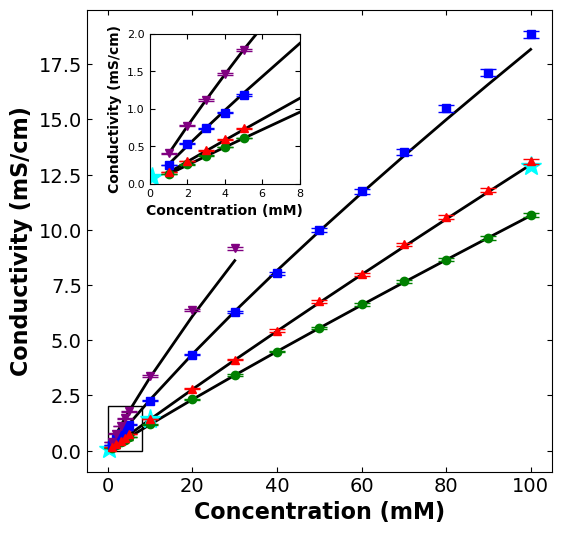

In [18]:
# plot comparing model predictions with probe 1 data
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=2, label="Shedlovsky")
ax.plot(molar_conc_specific_Na, specific_cond_calc_Na, "-", linewidth=2, color="black")
ax.plot(molar_conc_specific_Ca_fig, specific_cond_calc_Ca_fig, "-", linewidth=2, color="black")
ax.plot(molar_conc_specific_La_fig, specific_cond_calc_La_fig, "-", linewidth=2, color="black")
ax.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", label="NIST (KCl) Standard")
ax.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', 
    capsize=6, markersize=6, markerfacecolor='green', markeredgecolor='green', label='NaCl Data')
ax.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', 
    capsize=6, markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
ax.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', 
    capsize=6, markersize=6, markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
ax.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', 
    capsize=6, markersize=6, markerfacecolor='red', markeredgecolor='red', label='KCl Data')
ax.set_xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
ax.set_ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
ax.tick_params(labelsize=14, direction="in",top=True, right=True)

# define zoom region (clustered area)
zoom_xlim = (0, 8)
zoom_ylim = (0, 2)

# draw rectangle on main plot to show zoom area
ax.add_patch(
    plt.Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0],
        zoom_ylim[1] - zoom_ylim[0],
        fill=False
    )
)

# create inset axes on top left
inset_ax = fig.add_axes([0.23, 0.59, 0.25, 0.25])  # [left, bottom, width, height]

# plot the zoomed region
# repeat your plot data
inset_ax.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=2, label="Shedlovsky")
inset_ax.plot(molar_conc_specific_Na, specific_cond_calc_Na, "-", linewidth=2, color="black")
inset_ax.plot(molar_conc_specific_Ca_fig, specific_cond_calc_Ca_fig, "-", linewidth=2, color="black")
inset_ax.plot(molar_conc_specific_La_fig, specific_cond_calc_La_fig, "-", linewidth=2, color="black")
inset_ax.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", label="NIST (KCl) Standard")
inset_ax.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', capsize=6, 
    markersize=6, markerfacecolor='green', markeredgecolor='green', label='NaCl Data')
inset_ax.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', 
    capsize=6, markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
inset_ax.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', 
    capsize=6, markersize=6, markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
inset_ax.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', 
    capsize=6, markersize=6, markerfacecolor='red', markeredgecolor='red', label='KCl Data')
inset_ax.set_xlim(zoom_xlim)
inset_ax.set_ylim(zoom_ylim)
inset_ax.set_xlabel("Concentration (mM)", fontsize=10,fontweight='bold')
inset_ax.set_ylabel("Conductivity (mS/cm)", fontsize=10,fontweight='bold')
inset_ax.tick_params(labelsize=8, direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.savefig(r".\Single_salt\shed_single_all.png")
plt.show()

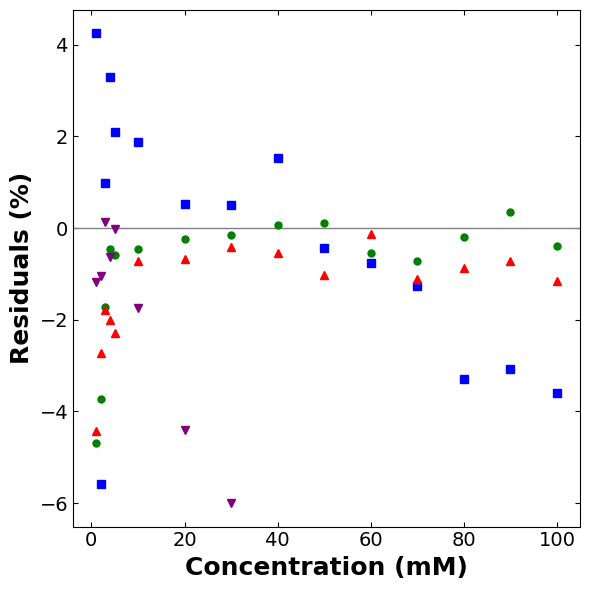

In [19]:
# plot the prediction residuals
fig = plt.figure(figsize=(6, 6))
plt.axhline(0, color="0.5", lw=1)
plt.plot(molar_conc_specific_Na, residuals_percent_Na, "g.", markersize=10, 
         label="NaCl")
plt.plot(molar_conc_specific_Ca_fig, residuals_percent_Ca, "s", color="blue", 
         label="CaCl$\mathbf{_2}$")
plt.plot(molar_conc_specific, residuals_percent_K, "^", color="red", label="KCl")
plt.plot(molar_conc_specific_La_fig, residuals_percent_La, "v", color="purple", 
         label="LaCl$\mathbf{_3}$")
plt.xlabel("Concentration (mM)", fontsize=18,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=18,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Single_salt\shed_single_all_residuals.png")
plt.show()

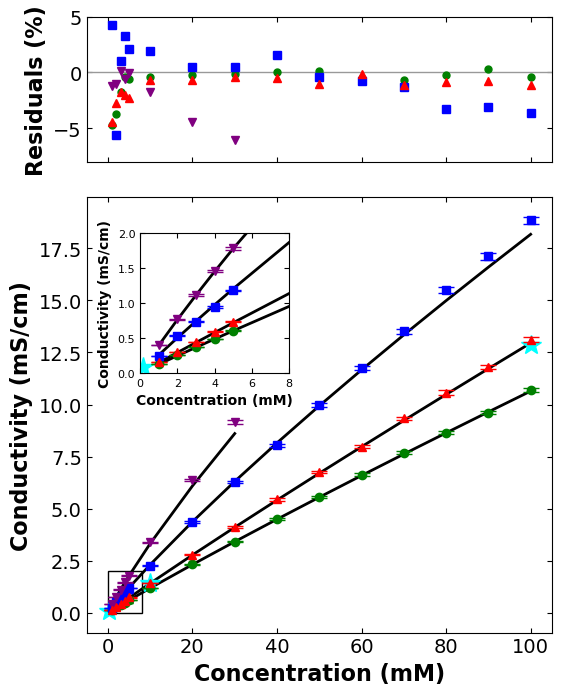

In [20]:
# generate paper figure for the Shedlovsky model
fig = plt.figure(figsize=(6, 8))
gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.12)

ax_res = fig.add_subplot(gs[0])
ax_cond = fig.add_subplot(gs[1], sharex=ax_res)

# top plot
ax_res.axhline(0, color="0.6", lw=1)
ax_res.plot(molar_conc_specific_Na, residuals_percent_Na, "g.", markersize=10, label="NaCl")
ax_res.plot(molar_conc_specific_Ca_fig, residuals_percent_Ca, "s", color="blue", label="CaCl$\mathbf{_2}$")
ax_res.plot(molar_conc_specific, residuals_percent_K, "^", color="red", label="KCl")
ax_res.plot(molar_conc_specific_La_fig, residuals_percent_La, "v", color="purple", label="LaCl$\mathbf{_3}$")

ax_res.set_ylabel("Residuals (%)", fontsize=16, fontweight="bold")
ax_res.set_ylim(-8, 5)
ax_res.tick_params(direction="in", top=True, right=True, labelsize=14)
plt.setp(ax_res.get_xticklabels(), visible=False)

# bottom plot
ax_cond.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=2, label="Shedlovsky")
ax_cond.plot(molar_conc_specific_Na, specific_cond_calc_Na, "-", linewidth=2, color="black")
ax_cond.plot(molar_conc_specific_Ca_fig, specific_cond_calc_Ca_fig, "-", linewidth=2, color="black")
ax_cond.plot(molar_conc_specific_La_fig, specific_cond_calc_La_fig, "-", linewidth=2, color="black")
ax_cond.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", label="NIST (KCl) Standard")
ax_cond.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', 
    capsize=6, markersize=6, markerfacecolor='green', markeredgecolor='green', label='NaCl Data')
ax_cond.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', 
    capsize=6, markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
ax_cond.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', 
    capsize=6, markersize=6, markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
ax_cond.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', capsize=6, 
    markersize=6, markerfacecolor='red', markeredgecolor='red', label='KCl Data')

ax_cond.set_xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
ax_cond.set_ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
ax_cond.tick_params(labelsize=14, direction="in",top=True, right=True)

ax_inset = inset_axes(
    ax_cond,
    width="40%", 
    height="40%",
    bbox_to_anchor=(0.1, 0.58, 0.8, 0.8),
    bbox_transform=ax_cond.transAxes,
    loc="lower left"
)

# plot subset
ax_inset.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=2, label="Shedlovsky")
ax_inset.plot(molar_conc_specific_Na, specific_cond_calc_Na, "-", linewidth=2, color="black")
ax_inset.plot(molar_conc_specific_Ca_fig, specific_cond_calc_Ca_fig, "-", linewidth=2, color="black")
ax_inset.plot(molar_conc_specific_La_fig, specific_cond_calc_La_fig, "-", linewidth=2, color="black")
ax_inset.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", label="NIST (KCl) Standard")
ax_inset.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', 
    capsize=6, markersize=6, markerfacecolor='green', markeredgecolor='green', label='NaCl Data')
ax_inset.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', 
    capsize=6, markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
ax_inset.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', 
    capsize=6, markersize=6,  markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
ax_inset.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', 
    capsize=6, markersize=6, markerfacecolor='red', markeredgecolor='red', label='KCl Data')

ax_inset.set_xlim(0, 8)
ax_inset.set_ylim(0, 2)
ax_inset.set_xlabel("Concentration (mM)", fontsize=10,fontweight='bold')
ax_inset.set_ylabel("Conductivity (mS/cm)", fontsize=10,fontweight='bold')
ax_inset.tick_params(labelsize=8, direction="in",top=True, right=True)

# define zoom region (clustered area)
zoom_xlim = (0, 8)
zoom_ylim = (0, 2)
ax_cond.add_patch(
    plt.Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0],
        zoom_ylim[1] - zoom_ylim[0],
        fill=False
    )
)
plt.savefig(r".\Single_salt\shed_single_all_final.png")
plt.show()


## Conductivity data from uncalibrated probe 1

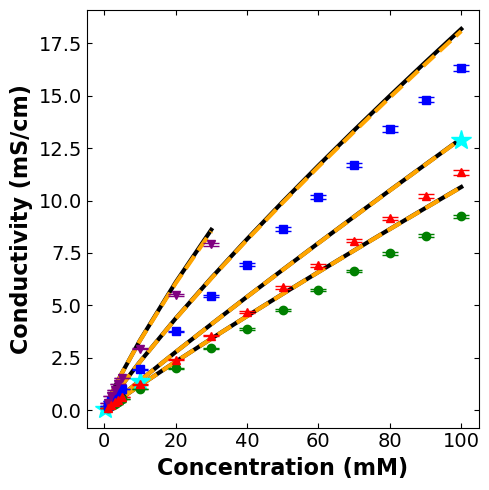

In [21]:
# plot comparing NIST standards with data from uncalibrated probe 1
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=3, label="Shedlovsky")
plt.plot(molar_conc_specific_Na, specific_cond_calc_Na, "-", linewidth=3, color="black")
plt.plot(molar_conc_specific_Ca_fig, specific_cond_calc_Ca_fig, "-", color="black", linewidth=3)
plt.plot(molar_conc_specific_La_fig, specific_cond_calc_La_fig, "-", color="black", linewidth=3)
plt.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, label="MSA")
plt.plot(molar_conc_specific_Na, msa_cond_calc_nacl, "--", color="orange", linewidth=3)
plt.plot(molar_conc_specific_Ca_fig, msa_cond_calc_cacl2, "--", color="orange", linewidth=3)
plt.plot(molar_conc_specific_La_fig, msa_cond_calc_lacl3, "--", color="orange", linewidth=3)
plt.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", label="NIST (KCl) Standard")
plt.errorbar(
    molar_conc_specific_Na, specific_cond_exp_Na, yerr=error_Na_uncal, fmt='o', ecolor='green', 
    capsize=6, markersize=6, markerfacecolor='green', markeredgecolor='green', label='NaCl Data')
plt.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_exp_Ca, yerr=error_Ca_uncal, fmt='s', ecolor='blue', 
    capsize=6, markersize=6, markerfacecolor='blue', markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
plt.errorbar(
    molar_conc_specific_La_fig, specific_cond_exp_La, yerr=error_La_uncal, fmt='v', ecolor='purple', 
    capsize=6, markersize=6, markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
plt.errorbar(
    molar_conc_specific, specific_cond_exp1, yerr=error_K_uncal, fmt='^', ecolor='red', 
    capsize=6, markersize=6, markerfacecolor='red', markeredgecolor='red', label='KCl Data')
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Single_salt\msa_shed_all_uncal.png")
plt.show()

In [22]:
# residuals of the uncalibrated data when compared to the Shedlovsky model
residuals_uncal = [specific_cond_exp1[i] - specific_cond_calc[i] 
                   for i in range(ndata_K)]
residuals_uncal_Na = [specific_cond_exp_Na[i] - specific_cond_calc_Na[i] 
                      for i in range(ndata_Na)]
e_Ca_uncal = [specific_cond_exp_Ca[i] - specific_cond_calc_Ca_fig[i] 
              for i in range(ndata_Ca_fig)]
e_La_uncal = [specific_cond_exp_La[i] - specific_cond_calc_La_fig[i] 
              for i in range(ndata_La_fig)]

# residuals of the uncalibrated data when compared to the MSA model
residuals_uncal_MSA = [specific_cond_exp1[i] - msa_cond_calc_kcl[i] 
                       for i in range(ndata_K)]
e_Na_uncal_MSA = [specific_cond_exp_Na[i] - msa_cond_calc_nacl[i] 
                  for i in range(ndata_Na)]
e_Ca_uncal_MSA = [specific_cond_exp_Ca[i] - msa_cond_calc_cacl2[i] 
                  for i in range(ndata_Ca_fig)]
e_La_uncal_MSA = [specific_cond_exp_La[i] - msa_cond_calc_lacl3[i] 
                  for i in range(ndata_La_fig)]

The NaCl mean percent error when compared to the Shedlovsky model is: -12.688961002908702
The KCl mean percent error when compared to the MSA model is: -12.264968452644716
The NaCl mean percent error when compared to the MSA model is: -12.617549766727993
The CaCl2 mean percent error when compared to the MSA model is: -12.960124110758956
The LaCl3 mean percent error when compared to the MSA model is: -11.479382403631135


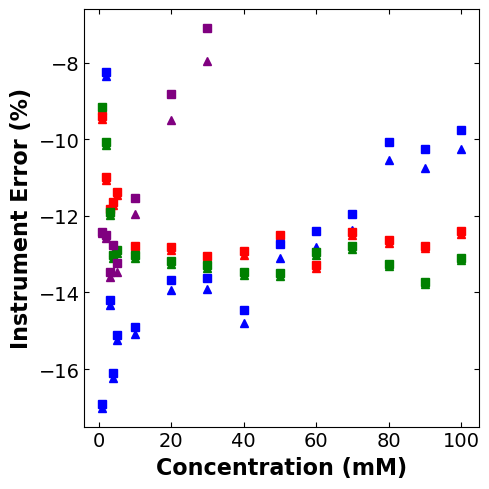

In [23]:
# percent error when compared to the Shedlovsky model
residuals_percent_uncal = [(residuals_uncal[i]/specific_cond_calc[i])*100 
                           for i in range(ndata_K)]
residuals_percent_Na_uncal = [(residuals_uncal_Na[i]/specific_cond_calc_Na[i])*100 
                              for i in range(ndata_Na)]
e_percent_Ca_uncal = [100*e_Ca_uncal[i]/specific_cond_calc_Ca_fig[i] 
                      for i in range(ndata_Ca_fig)]
e_percent_La_uncal = [100*e_La_uncal[i]/specific_cond_calc_La_fig[i] 
                      for i in range(ndata_La_fig)]

# percent error when compared to the MSA model
residuals_percent_uncal_MSA = [(residuals_uncal_MSA[i]/msa_cond_calc_kcl[i])*100 
                               for i in range(ndata_K)]
e_percent_Na_uncal_MSA = [100*e_Na_uncal_MSA[i]/msa_cond_calc_nacl[i] 
                          for i in range(ndata_Na)]
e_percent_Ca_uncal_MSA = [100*e_Ca_uncal_MSA[i]/msa_cond_calc_cacl2[i] 
                          for i in range(ndata_Ca_fig)]
e_percent_La_uncal_MSA = [100*e_La_uncal_MSA[i]/msa_cond_calc_lacl3[i] 
                          for i in range(ndata_La_fig)]

# mean percent error when compared to the Shedlovsky model
residual_percent_avg = np.average(residuals_percent_Na_uncal)
print("The NaCl mean percent error when compared to the Shedlovsky model is:",
      residual_percent_avg)

# mean percent error when compared to the MSA model
residual_percent_avg = np.average(residuals_percent_uncal)
e_percent_Na_uncal_MSA_avg = np.average(e_percent_Na_uncal_MSA)
e_percent_Ca_uncal_MSA_avg = np.average(e_percent_Ca_uncal_MSA)
e_percent_La_uncal_MSA_avg = np.average(e_percent_La_uncal_MSA)
print("The KCl mean percent error when compared to the MSA model is:",
      residual_percent_avg)
print("The NaCl mean percent error when compared to the MSA model is:",
      e_percent_Na_uncal_MSA_avg)
print("The CaCl2 mean percent error when compared to the MSA model is:",
      e_percent_Ca_uncal_MSA_avg)
print("The LaCl3 mean percent error when compared to the MSA model is:",
      e_percent_La_uncal_MSA_avg)

# visualizing
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, residuals_percent_uncal, "^", color="red", 
         label="Shedlovsky KCl")
plt.plot(molar_conc_specific_Na, residuals_percent_Na_uncal, "^", color="green", 
         label="Shedlovsky NaCl")
plt.plot(molar_conc_specific_Ca_fig, e_percent_Ca_uncal, "^", color="blue", 
         label="Shedlovsky CaCl$\mathbf{_2}$")
plt.plot(molar_conc_specific_La_fig, e_percent_La_uncal, "^", color="purple", 
         label="Shedlovsky LaCl$\mathbf{_3}$")
plt.plot(molar_conc_specific, residuals_percent_uncal_MSA, "s", color="red", 
         label="MSA KCl")
plt.plot(molar_conc_specific_Na, e_percent_Na_uncal_MSA, "s", color="green", 
         label="MSA NaCl")
plt.plot(molar_conc_specific_Ca_fig, e_percent_Ca_uncal_MSA, "s", color="blue", 
         label="MSA CaCl$\mathbf{_2}$")
plt.plot(molar_conc_specific_La_fig, e_percent_La_uncal_MSA, "s", color="purple", 
         label="MSA LaCl$\mathbf{_3}$")
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Instrument Error (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Single_salt\msa_shed_all_residuals_uncal.png")
plt.show()

## KCl Probe 2

### Uncalibrated Data

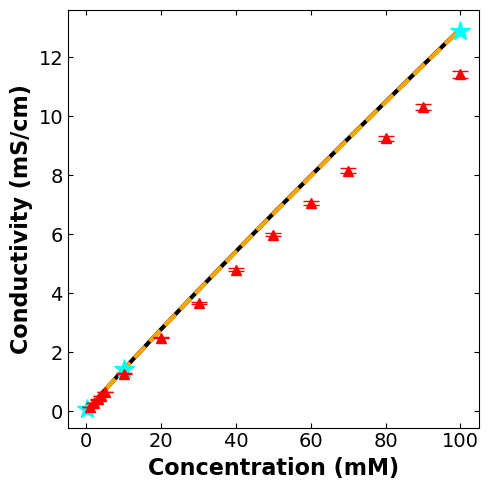

In [24]:
# plot comparing NIST standards with probe 2 uncalibrated data
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=3, 
         label="Shedlovsky")
plt.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, 
         label="MSA")
plt.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", 
         label="NIST (KCl) Standard")
plt.errorbar(
    molar_conc_specific, specific_cond_exp2, yerr=error_K_uncal_2, fmt='^', ecolor='red', 
    capsize=6, markersize=7, markerfacecolor='red', markeredgecolor='red', label='KCl Data')
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Single_salt\msa_shed_all_uncal_probe2.png")
plt.show()

In [25]:
# residuals of the uncalibrated data when compared to the Shedlovsky model
residuals_uncal_probe2 = [specific_cond_exp2[i] - specific_cond_calc[i] 
                          for i in range(ndata_K)]

# residuals of the uncalibrated data when compared to the MSA model
e_MSA_uncal_probe2 = [specific_cond_exp2[i]- msa_cond_calc_kcl[i] 
                      for i in range(ndata_K)]

The mean percent error when compared to the Shedlovsky is: -10.610511709706518
The mean percent error when compared to the MSA is: -10.529052427021352


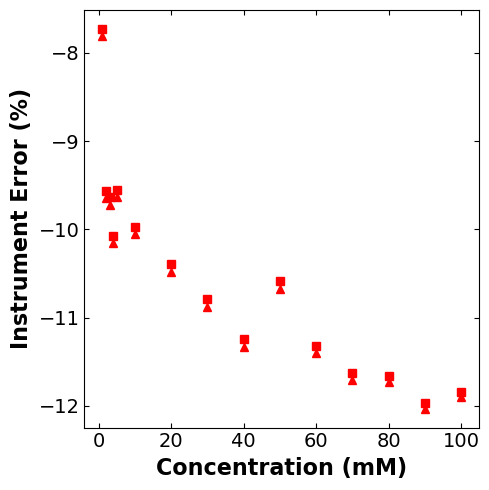

In [26]:
# percent error when compared to the Shedlovsky and MSA models
e_percent_uncal_probe2 = [(residuals_uncal_probe2[i]/specific_cond_calc[i])*100 
                          for i in range(ndata_K)]
e_percent_MSA_uncal_probe2 = [(e_MSA_uncal_probe2[i]/msa_cond_calc_kcl[i])*100 
                              for i in range(ndata_K)]

# mean percent error when compared to the Shedlovsky and MSA models
e_percent_avg_probe2_uncal = np.mean(e_percent_uncal_probe2)
e_percent_avg_MSA_probe2_uncal = np.mean(e_percent_MSA_uncal_probe2)
print("The mean percent error when compared to the Shedlovsky is:",
      e_percent_avg_probe2_uncal)
print("The mean percent error when compared to the MSA is:",
      e_percent_avg_MSA_probe2_uncal)

# visualizing
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, e_percent_uncal_probe2, "^", color="red", 
         label="Shedlovsky")
plt.plot(molar_conc_specific, e_percent_MSA_uncal_probe2, "s", color="red", 
         label="MSA")
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Instrument Error (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Single_salt\msa_var_shed_all_residuals_uncal_probe2.png")
plt.show()

### Calibrated Data

In [27]:
specific_cond_calibrated_exp2_raw = specific_data_probe2["Cond Cal"]

# convert the conductivity from micro.S/cm to milli.S/cm
specific_cond_calibrated_exp2 = [specific_cond_calibrated_exp2_raw[i]/1000 
                                 for i in range(ndata_K)]

# compute the measurement error
error_K_2 = [(mape_probe2/100) * specific_cond_calibrated_exp2[i] 
             for i in range(ndata_K)]

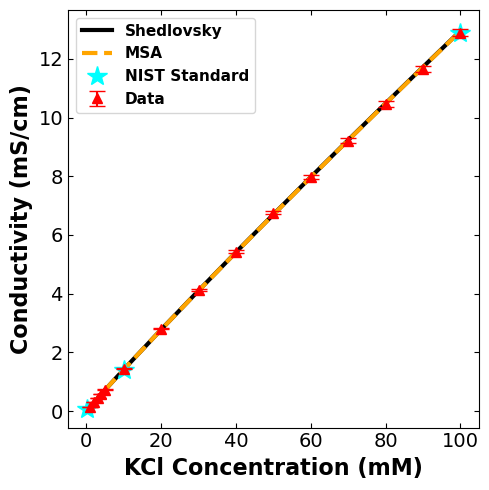

In [28]:
# plot comparing probe 2 uncalibrated data with the model predictions
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=3, 
         label="Shedlovsky")
plt.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, 
         label="MSA")
plt.plot(molar_conc_nist, nist_cond, "*", markersize=15, color="cyan", 
         label="NIST Standard")
plt.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp2, yerr=error_K_2, fmt='^', ecolor='red', 
    capsize=6, markersize=7, markerfacecolor='red', markeredgecolor='red', label='Data')
plt.xlabel("KCl Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Single_salt\msa_var_shed_all_probe2.png")
plt.show()

The mean absolute percent error for the Shedlovsky model is: 1.1974156882726956
The mean absolute percent error for the MSA model is: 1.2449281447878777


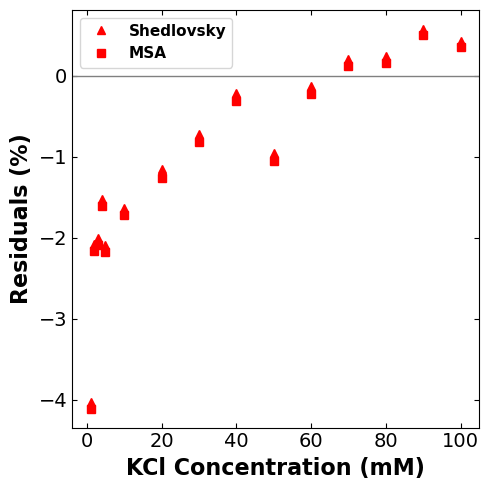

In [29]:
# Shedlovsky prediction residuals for probe 2 data
residuals_probe2 = [specific_cond_calc[i] - specific_cond_calibrated_exp2[i] 
                    for i in range(ndata_K)]

# MSA prediction residuals for probe 2 data
e_MSA_probe2 = [msa_cond_calc_kcl[i]- specific_cond_calibrated_exp2[i] 
                for i in range(ndata_K)]

# percent residuals
e_percent_probe2 = [(residuals_probe2[i]/specific_cond_calibrated_exp2[i])*100 
                    for i in range(ndata_K)]
e_percent_MSA_probe2 = [(e_MSA_probe2[i]/specific_cond_calibrated_exp2[i])*100 
                        for i in range(ndata_K)]

# calculate the mean absolute percent error
e_percent_probe2_abs = [np.abs(e_percent_probe2[i]) for i in range(ndata_K)]
e_percent_MSA_probe2_abs = [np.abs(e_percent_MSA_probe2[i]) for i in range(ndata_K)]
avg_e_percent_probe2_abs = np.mean(e_percent_probe2_abs)
avg_e_percent_MSA_probe2_abs = np.mean(e_percent_MSA_probe2_abs)
print("The mean absolute percent error for the Shedlovsky model is:",
      avg_e_percent_probe2_abs)
print("The mean absolute percent error for the MSA model is:",
      avg_e_percent_MSA_probe2_abs)

# visualizing
fig = plt.figure(figsize=(5, 5))
plt.axhline(0, color="0.5", lw=1)
plt.plot(molar_conc_specific, e_percent_probe2, "^", color="red", label="Shedlovsky")
plt.plot(molar_conc_specific, e_percent_MSA_probe2, "s", color="red", label="MSA")
plt.xlabel("KCl Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold", "size": 11},)
plt.tight_layout()
plt.savefig(r".\Single_salt\msa_var_shed_all_residuals_probe2.png")
plt.show()